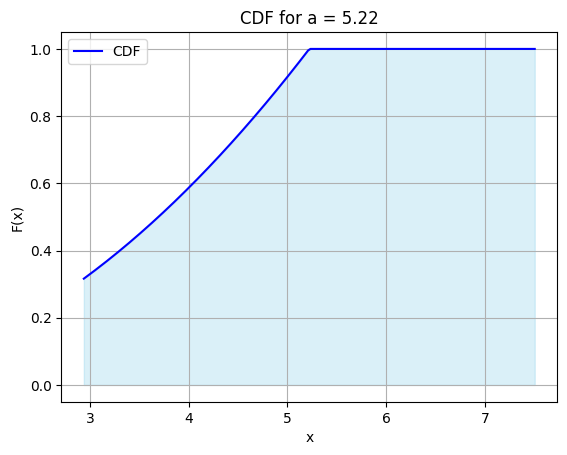

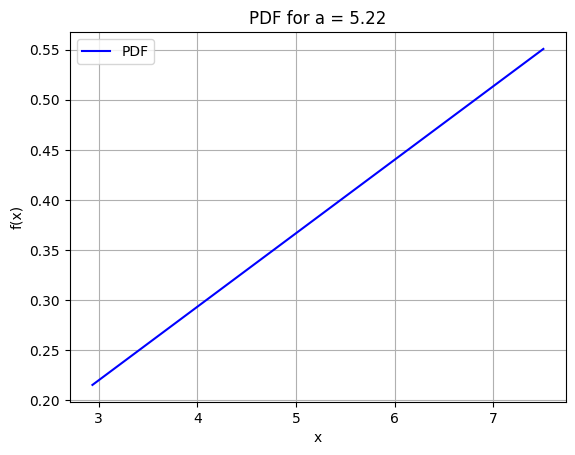

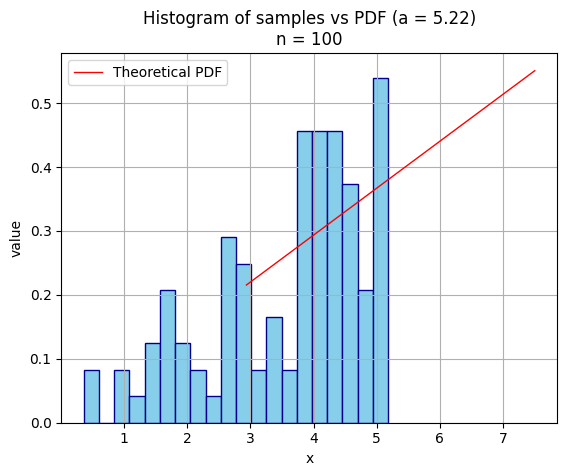

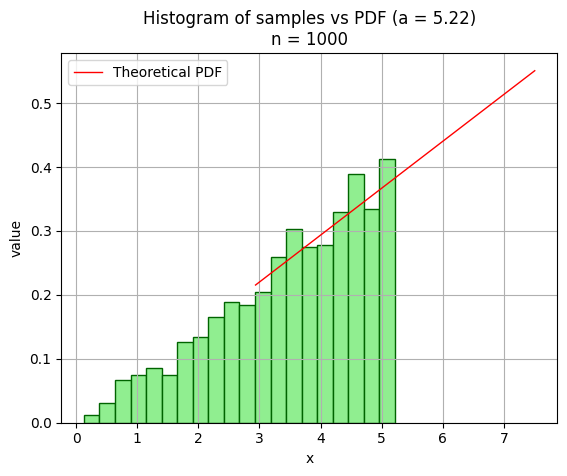

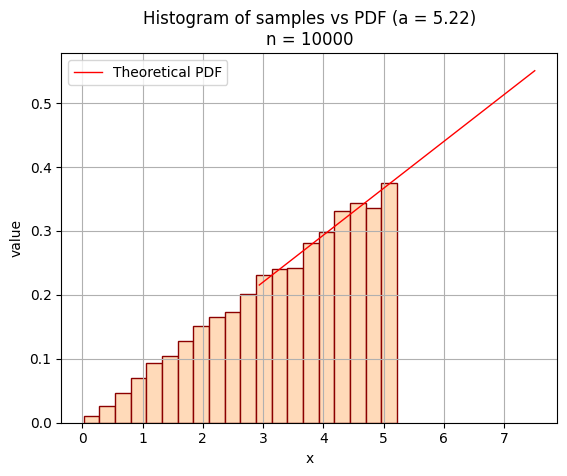

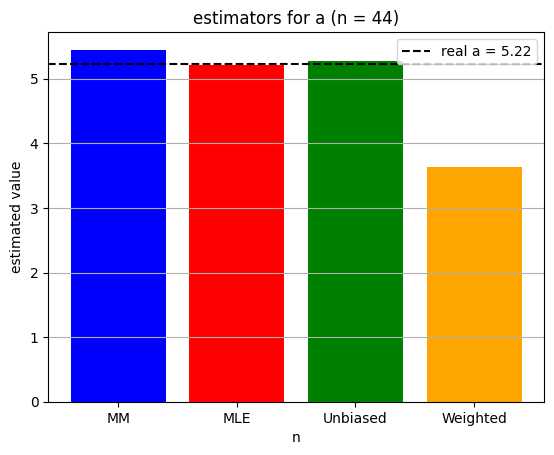

MSE (n=44, a=5.22):
MM MSE: 0.0877
MLE MSE: 0.0074
Unbiased MSE: 0.0033
Weighted MSE: 3.0277

RMSE (n=44, a=5.22):
MM: 0.2690
MLE: 0.0957
Unbiased: 0.0567


In [14]:
# @title helper functions
import numpy as np
import matplotlib.pyplot as plt

a = np.random.uniform(0, 10)
r = np.random.uniform(1, 5)
x = np.linspace(a - r, a + r, 200)

def F(x, a):
  if x<=0:
    return 0
  elif x>=a:
    return 1
  else:
    if 0<x<a:
      return x**2/a**2


def f(x, a):
    x = np.array(x)
    np.where((0 < x) and (x < a), 2 * x / (a**2), 0)


def inv_cdf(u, a):
  x = np.sqrt(u) * a
  return x



def sample_from_f(n, a):
  u = np.random.uniform(0, 1, n)
  samples = inv_cdf(u, a)
  return samples

#graph q_1
cdf_vals = [F(xi, a) for xi in x]
pdf_vals = 2 * x / a**2
plt.plot(x, cdf_vals, label="CDF", color="blue")
plt.fill_between(x, cdf_vals, color="skyblue", alpha=0.3)
plt.title(f"CDF for a = {a:.2f}")
plt.xlabel("x")
plt.ylabel("F(x)")
plt.grid(True)
plt.legend()
plt.show()


plt.plot(x, pdf_vals, label="PDF", color="blue")
plt.title(f"PDF for a = {a:.2f}")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()



def estimate_mm(x):
  return 1.5 * np.mean(x)


def estimate_mle(x):
  return np.max(x)


#### Two options (weighted avg) :
# option 1: choose weighted avg (sum of weights are not summed to 1)
def estimate_weighted_unbiased(x):
  n = len(x)
  return ((2*n+1) / (2*n)) * estimate_mle(x)

# option 2: choose weighted avg (sum of weights  is 1)
def estimate_weighted_avg(x):
  return sum(x)/len(x)


#graph_q3
n = np.random.randint(0,100)
samples = sample_from_f(n, a)
n1 = 100
n2 = 1000
n3 = 10000
samples1 = sample_from_f(n1, a)
samples2 = sample_from_f(n2, a)
samples3 = sample_from_f(n3, a)

plt.figure(1)
plt.hist(samples1, bins=20, density=True, edgecolor='darkblue', color='skyblue')
plt.plot(x, pdf_vals, color='red', label="Theoretical PDF", linewidth=1)
plt.title(f"Histogram of samples vs PDF (a = {a:.2f})\nn = {n1}")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(2)
plt.hist(samples2, bins=20, density=True, edgecolor='darkgreen', color='lightgreen')
plt.plot(x, pdf_vals, color='red', label="Theoretical PDF", linewidth=1)
plt.title(f"Histogram of samples vs PDF (a = {a:.2f})\nn = {n2}")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(3)
plt.hist(samples3, bins=20, density=True, edgecolor='darkred', color='peachpuff')
plt.plot(x, pdf_vals, color='red', label="Theoretical PDF", linewidth=1)
plt.title(f"Histogram of samples vs PDF (a = {a:.2f})\nn = {n3}")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()

#graph_q4
labels = ['MM', 'MLE', 'Unbiased', 'Weighted']
values = [estimate_mm(samples), estimate_mle(samples), estimate_weighted_unbiased(samples), estimate_weighted_avg(samples)]

plt.bar(labels, values, color=['blue', 'red', 'green', 'orange'])
plt.axhline(a, linestyle='--', color='black', label=f"real a = {a:.2f}")
plt.title(f"estimators for a (n = {n})")
plt.ylabel("estimated value")
plt.xlabel("n")
plt.legend()
plt.grid(axis='y')
plt.show()

#q5
k=100
def MSE(function, a, n):
  errors = []
  for _ in range(k):
    sample = sample_from_f(n, a)
    a_hat = function(sample)
    error = (a_hat - a)**2
    errors.append(error)
  return np.mean(errors)

mse_mm = MSE(estimate_mm, a, n)
mse_mle = MSE(estimate_mle, a, n)
mse_unbiased = MSE(estimate_weighted_unbiased, a, n)
mse_weighted = MSE(estimate_weighted_avg, a, n)

print(f"MSE (n={n}, a={a:.2f}):")
print(f"MM MSE: {mse_mm:.4f}")
print(f"MLE MSE: {mse_mle:.4f}")
print(f"Unbiased MSE: {mse_unbiased:.4f}")
print(f"Weighted MSE: {mse_weighted:.4f}\n")

def RMSE(function, a, n):
    mse = MSE(function, a, n)
    return np.sqrt(mse)

rmse_mm = RMSE(estimate_mm, a, n)
rmse_mle = RMSE(estimate_mle, a, n)
rmse_unbiased = RMSE(estimate_weighted_unbiased, a, n)

print(f"RMSE (n={n}, a={a:.2f}):")
print(f"MM: {rmse_mm:.4f}")
print(f"MLE: {rmse_mle:.4f}")
print(f"Unbiased: {rmse_unbiased:.4f}")